# Bates Grain Interface

In [17]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import tensorflow as tf
from scipy.integrate import trapezoid
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from tensorflow.keras.models import load_model

# ==========================================
# 1. Loading Model and Scalers
# ==========================================
print("Loading Final Inverse Model and Scalers...")
try:
    # 1. تحميل النموذج (بدون compile)
    my_inverse_model = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Bates Models\\Bates_Inverse_Model_Final.keras', compile=False)
    
    # 2. تحميل الـ 4 Scalers بالأسماء الجديدة
    my_s_X = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Bates Models\\scaler_dimensions_inv_final.pkl')
    my_s_yt = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Bates Models\\scaler_thrust_inv_final.pkl')
    my_s_yp = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Bates Models\\scaler_pressure_inv_final.pkl')
    my_s_ys = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Bates Models\\scaler_scalars_inv_final.pkl')
    
    print(" Model and All 4 Scalers loaded successfully!\n")
except Exception as e:
    print(f" Error loading files: {e}")
    raise e

# ==========================================
# 2. Prediction Function
# ==========================================
def predict_dimensions_perfect_match(file_path, inverse_model, s_X, s_yt, s_yp, s_ys, original_df=None, n_iter=200):
    print(f"\nProcessing file: {file_path}")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # 1. قراءة الملف
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df_file = pd.read_excel(file_path)
    else:
        df_file = pd.read_csv(file_path, sep=None, engine='python', encoding='latin1', on_bad_lines='skip', skip_blank_lines=True)
    
    # 2. التعرف الآلي على الأعمدة
    col_map = {}
    for col in df_file.columns:
        col_clean = str(col).lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if 'time' in col_clean or col_clean == 't':
            col_map['time'] = col
        elif 'thrust' in col_clean or col_clean == 'f':
            col_map['thrust'] = col
        elif 'pressure' in col_clean or col_clean == 'p':
            col_map['pressure'] = col

    # ترتيب البيانات وحذف الخلايا الفارغة
    df_file = df_file.sort_values(col_map['time']).dropna(subset=[col_map['time'], col_map['thrust'], col_map['pressure']])
    
    #  نأخذ المنحنى كامل بدون أي قص (مطابقة 1:1 مع داتا التدريب)
    t        = df_file[col_map['time']].values
    thrust   = df_file[col_map['thrust']].values
    pressure = df_file[col_map['pressure']].values

    # التنعيم والاستيفاء لـ 100 نقطة
    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # 3. استخراج الـ ID الحقيقي والبحث عنه في الداتا الأصلية (إن وُجدت)
    filename = os.path.basename(file_path)
    match = re.search(r'(\d+)', filename)
    
    isp_true = None
    total_impulse_true = None
    
    if match and original_df is not None:
        file_id = int(match.group(1)) 
        matching_case = original_df[original_df['ID'] == file_id]
        
        if not matching_case.empty:
            isp_true = matching_case['ISP (s)'].iloc[0]
            total_impulse_true = matching_case['Total Impulse (Ns)'].iloc[0]
            print(f" Successfully matched ID [{file_id}] in original dataset!")
            print(f"   Real Data Specs -> ISP: {isp_true:.2f} s | Total Impulse: {total_impulse_true:.2f} N.s")
    
    # حل احتياطي صارم إذا لم يجد الـ ID أو لم يتم تمرير original_df
    if isp_true is None:
        # افتراض قيمة للـ ISP (تم تعيين 170.0 بناءً على الكود الخاص بك، يمكنك تعديلها)
        isp_true = 170.1542764

        total_impulse_true = trapezoid(thrust, t)
        print(f" ID not found in dataset (or df not provided). Using calculated backup values.")

        

    burn_time = t[-1] 
    max_thrust = np.max(thrust)
    
    # المتغيرات الأربعة الثابتة المتطابقة مع الـ Scaler الأصلي
    scalars = np.array([isp_true, total_impulse_true, burn_time, max_thrust])

    print("\n Extracted Raw Scalars Passed to Scaler:")
    print(f"   - Burn Time:    {burn_time:.3f} s")
    print(f"   - Max Thrust:   {max_thrust:.2f} N")
    print(f"   - Total Impulse:{total_impulse_true:.2f} N.s")
    print(f"   - ISP:          {isp_true:.2f} s")

    # 4. التقييس (Scaling)
    t_scaled = s_yt.transform(thrust_100.reshape(1, -1))
    p_scaled = s_yp.transform(pressure_100.reshape(1, -1))
    s_scaled = s_ys.transform(scalars.reshape(1, -1))

    # 5. التنبؤ بـ MC Dropout لضمان الحركية وعدم التكرار
    t_tensor = tf.constant(t_scaled, dtype=tf.float32)
    p_tensor = tf.constant(p_scaled, dtype=tf.float32)
    s_tensor = tf.constant(s_scaled, dtype=tf.float32)
    
    preds = []
    for _ in range(n_iter):
        out = inverse_model([t_tensor, p_tensor, s_tensor], training=True) 
        preds.append(out.numpy())
        
    preds_arr = np.stack(preds, axis=0)
    pred_mean_s = preds_arr.mean(axis=0)
    
    # إلغاء التقييس بالـ MinMaxScaler
    pred_dims = s_X.inverse_transform(pred_mean_s)[0]
    pred_dims = np.maximum(pred_dims, 0.1)

    print("\n" + "="*55)
    print("   Final Predicted Dimensions (1:1 Match)")
    print("="*55)
    labels = [
        'Length      (Grain Length)  ',
        'Outer Dia   (Outer Diameter)',
        'Inner Dia   (Core Diameter) ',
        'Throat Dia  (Throat Dia)    ',
        'Exit Dia    (Exit Diameter) ' 
    ]
    for label, val in zip(labels, pred_dims):
        print(f"  {label}: {val:.4f} cm")
    print("="*55)

    return dict(zip(['Length', 'Outer_Dia', 'Inner_Dia', 'Throat_Dia', 'Exit_Dia'], pred_dims))

# =======================================================
# 3. Execution
# =======================================================
if __name__ == "__main__":
    file_path = "M:\\Graduation Project\\Team B\\Code_project\\test models\\3000.0.xlsx"
    
    
    predicted_dims = predict_dimensions_perfect_match(
        file_path, 
        my_inverse_model, 
        my_s_X, 
        my_s_yt, 
        my_s_yp, 
        my_s_ys
    )

Loading Final Inverse Model and Scalers...
 Model and All 4 Scalers loaded successfully!


Processing file: M:\Graduation Project\Team B\Code_project\test models\3000.0.xlsx


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


 ID not found in dataset (or df not provided). Using calculated backup values.

 Extracted Raw Scalars Passed to Scaler:
   - Burn Time:    5.465 s
   - Max Thrust:   17118.28 N
   - Total Impulse:37091.01 N.s
   - ISP:          170.15 s

   Final Predicted Dimensions (1:1 Match)
  Length      (Grain Length)  : 121.0960 cm
  Outer Dia   (Outer Diameter): 11.9545 cm
  Inner Dia   (Core Diameter) : 3.7919 cm
  Throat Dia  (Throat Dia)    : 2.7080 cm
  Exit Dia    (Exit Diameter) : 4.0600 cm


# C Grain Interface

In [ ]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os

from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

# ============================================================
# CUSTOM LOSS
# ============================================================

def weighted_mse(y_true, y_pred):

    weights = tf.constant(
        [1.5, 2.0, 1.5, 1.5, 4.0, 4.0],
        dtype=tf.float32
    )

    error = tf.square(y_true - y_pred)

    weighted_error = error * weights

    return tf.reduce_mean(weighted_error)

# ============================================================
# CONFIG
# ============================================================

MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\C Models\\C_Reverse.keras"

SCALAR_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\C Models\\c_rev_scaler_scalars.pkl"

DIMS_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\C Models\\c_rev_scaler_dims.pkl"

# ============================================================
# DIMENSIONS INFO
# ============================================================

DIM_NAMES = [
    'Length',
    'Diameter',
    'Slot_Width',
    'Slot_Offset',
    'Throat_Diameter',
    'Exit_Diameter'
]

# ضع الحدود الحقيقية المستخدمة أثناء التدريب
BOUNDS_MIN = np.array([20, 6, 0.5, 1, 0.2, 1.2], dtype=np.float32)
BOUNDS_MAX = np.array([130, 20, 4, 7, 2.0, 3.0], dtype=np.float32)

# ============================================================
# SCALAR NAMES
# ============================================================

SCALAR_COLS = [
    'Max Thrust (N)',
    'Avg Thrust (N)',
    'Total Impulse (Ns)',
    'Peak Pressure (MPa)',
    'Burn Time (s)',
]

# ============================================================
# LOAD MODEL + SCALERS مرة واحدة فقط
# ============================================================

print("=" * 60)
print("Loading model and scalers...")
print("=" * 60)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

s_xs_l = joblib.load(SCALAR_SCALER_PATH)
s_Y_l  = joblib.load(DIMS_SCALER_PATH)

print("✅ Model Loaded")
print("✅ Scalers Loaded")

# ============================================================
# HELPERS
# ============================================================

def compute_scalars_from_curve(t, thrust, pressure):
    """
    حساب الـ 5 scalars من المنحنيات.
    """

    max_thrust    = float(np.max(thrust))
    avg_thrust    = float(np.mean(thrust))
    total_impulse = float(trapezoid(thrust, t))
    peak_pressure = float(np.max(pressure))
    burn_time     = float(t[-1] - t[0])

    return [
        max_thrust,
        avg_thrust,
        total_impulse,
        peak_pressure,
        burn_time
    ]


def smart_col(df, keywords, exclude=None):
    """
    البحث الذكي عن الأعمدة.
    """

    exclude = exclude or []

    for col in df.columns:

        cl = (
            col.lower()
            .replace(' ', '')
            .replace('_', '')
            .replace('(', '')
            .replace(')', '')
            .replace('/', '')
            .replace('.', '')
        )

        if any(kw in cl for kw in keywords) and not any(ex in cl for ex in exclude):
            return col

    return None

# ============================================================
# GLOBAL RESULTS STORAGE
# ============================================================

all_results = []

# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================

def predict_file(
    file_path,
    actual_dims=None,
    num_points=200
):

    # ========================================================
    # READ FILE
    # ========================================================

    if file_path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)

    else:
        df = pd.read_csv(
            file_path,
            sep=None,
            engine='python',
            encoding='latin1',
            on_bad_lines='skip'
        )

    df.columns = df.columns.str.strip()

    # ========================================================
    # DETECT COLUMNS
    # ========================================================

    t_col = smart_col(
        df,
        ['time'],
        exclude=['total', 'burn']
    )

    th_col = smart_col(
        df,
        ['thrust'],
        exclude=['max', 'avg', 'total', 'mean']
    )

    pr_col = smart_col(
        df,
        ['pressure'],
        exclude=['peak', 'max']
    )

    if not all([t_col, th_col, pr_col]):

        raise ValueError(
            f'\n❌ أعمدة ناقصة!\n'
            f'  time     = {t_col}\n'
            f'  thrust   = {th_col}\n'
            f'  pressure = {pr_col}\n'
            f'\nالمتاح:\n{list(df.columns)}'
        )

    # ========================================================
    # CLEAN DATA
    # ========================================================

    df = (
        df
        .sort_values(t_col)
        .dropna(subset=[t_col, th_col, pr_col])
        .reset_index(drop=True)
    )

    t        = df[t_col].values.astype(float)
    thrust   = df[th_col].values.astype(float)
    pressure = df[pr_col].values.astype(float)

    # ========================================================
    # COMPUTE SCALARS
    # ========================================================

    scalars = compute_scalars_from_curve(
        t,
        thrust,
        pressure
    )

    # ========================================================
    # DIAGNOSTICS
    # ========================================================

    print(f'\n{"="*60}')
    print(f'FILE: {os.path.basename(file_path)}')
    print(f'{"="*60}')

    centers = s_xs_l.center_
    scales  = s_xs_l.scale_

    all_ok = True

    for i, (name, val) in enumerate(zip(SCALAR_COLS, scalars)):

        z = (val - centers[i]) / (scales[i] + 1e-8)

        ok = abs(z) < 3

        if not ok:
            all_ok = False

        print(
            f'{name:<25}: '
            f'{val:>12.3f}   '
            f'z={z:+.2f}   '
            f'{"✅" if ok else "⚠️ خارج النطاق"}'
        )

    if all_ok:
        print('\n✅ كل الـ scalars داخل نطاق التدريب')

    # ========================================================
    # INTERPOLATION
    # ========================================================

    x_new = np.linspace(t[0], t[-1], num_points)

    thrust_interp = interp1d(
        t,
        thrust,
        fill_value='extrapolate'
    )(x_new)

    pressure_interp = interp1d(
        t,
        pressure,
        fill_value='extrapolate'
    )(x_new)

    # ========================================================
    # NORMALIZATION
    # ========================================================

    thrust_interp = thrust_interp / (
        np.max(np.abs(thrust_interp)) + 1e-8
    )

    pressure_interp = pressure_interp / (
        np.max(np.abs(pressure_interp)) + 1e-8
    )

    # ========================================================
    # BUILD MODEL INPUTS
    # ========================================================

    curves = np.stack(
        [thrust_interp, pressure_interp],
        axis=-1
    )

    curves = curves.reshape(
        1,
        num_points,
        2
    ).astype(np.float32)

    scalars_s = s_xs_l.transform([scalars])

    # ========================================================
    # PREDICTION
    # ========================================================

    pred_s = model.predict(
        [curves, scalars_s],
        verbose=0
    )

    pred_dims = s_Y_l.inverse_transform(pred_s)[0]

    # Clip داخل الحدود
    pred_dims = np.clip(
        pred_dims,
        BOUNDS_MIN,
        BOUNDS_MAX
    )

    # ========================================================
    # RESULTS
    # ========================================================

    print(f'\n{"-"*70}')
    print(
        f'{"Dimension":<20}'
        f'{"Predicted":>12}',
        end=''
    )

    if actual_dims:
        print(
            f'{"Actual":>12}'
            f'{"Error %":>12}',
            end=''
        )

    print()
    print(f'{"-"*70}')

    results = {}

    for name, pred, lo, hi in zip(
        DIM_NAMES,
        pred_dims,
        BOUNDS_MIN,
        BOUNDS_MAX
    ):

        line = f'{name:<20}{pred:>12.4f}'

        if actual_dims and name in actual_dims:

            actual = actual_dims[name]

            err = abs(pred - actual) / (actual + 1e-8) * 100

            if err < 10:
                flag = '✅'

            elif err < 25:
                flag = '🟡'

            else:
                flag = '🔴'

            line += (
                f'{actual:>12.4f}'
                f'{err:>10.2f}%  '
                f'{flag}'
            )

        print(line)

        results[name] = pred

                # ====================================================
        # STORE RESULTS
        # ====================================================

        row = {
            'File': os.path.basename(file_path),
            'Dimension': name,
            'Predicted': float(pred)
        }

        if actual_dims and name in actual_dims:

            actual = actual_dims[name]

            err = abs(pred - actual) / (actual + 1e-8) * 100

            row['Actual'] = float(actual)
            row['Error_%'] = float(err)

        else:

            row['Actual'] = np.nan
            row['Error_%'] = np.nan

        all_results.append(row)

    print(f'{"-"*70}')

    return results

r1 = predict_file(
    r"M:\\Graduation Project\\Team B\\Code_project\\test models\data\\C_1207.0.xlsx",

    actual_dims={
        'Length': 40,
        'Diameter': 20,
        'Slot_Width': 1.5,
        'Slot_Offset': 4.5,
        'Throat_Diameter': 1.3,
        'Exit_Diameter': 1.95
    }
)

print('\n')
print('=' * 70)
print('TEST 2')
print('=' * 70)

r4 = predict_file(
        r"M:\\Graduation Project\\Team B\\Code_project\\test models\\data\\C_4613.0.xlsx",

    actual_dims={
        'Length': 120,
        'Diameter': 20,
        'Slot_Width': 3.5,
        'Slot_Offset': 2,
        'Throat_Diameter': 2,
        'Exit_Diameter': 3
    }
)


Loading model and scalers...
✅ Model Loaded
✅ Scalers Loaded

FILE: C_1207.0.xlsx
Max Thrust (N)           :     3963.336   z=+0.06   ✅
Avg Thrust (N)           :     2220.844   z=+0.05   ✅
Total Impulse (Ns)       :    37465.638   z=+0.05   ✅
Peak Pressure (MPa)      :       22.727   z=+0.48   ✅
Burn Time (s)            :       16.865   z=+0.17   ✅

✅ كل الـ scalars داخل نطاق التدريب

----------------------------------------------------------------------
Dimension              Predicted      Actual     Error %
----------------------------------------------------------------------
Length                   38.6028     40.0000      3.49%  ✅
Diameter                 19.8533     20.0000      0.73%  ✅
Slot_Width                1.5004      1.5000      0.03%  ✅
Slot_Offset               4.7703      4.5000      6.01%  ✅
Throat_Diameter           1.2789      1.3000      1.63%  ✅
Exit_Diameter             1.9180      1.9500      1.64%  ✅
----------------------------------------------------------

# D Grain Interface

In [18]:
# ══════════════════════════════════════════════════════
# Grain-D Inverse — Inference Interface (v2 Fixed)
# ══════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# ── Load model & scalers ──
inverse_model = tf.keras.models.load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\D Models\\GrainD_inverse_model.keras')
s_X  = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\D Models\\grainD_inv_scaler_dims.pkl')
s_yt = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\D Models\\grainD_inv_scaler_thrust.pkl')
s_yp = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\D Models\\grainD_inv_scaler_pressure.pkl')
s_ys = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\D Models\\grainD_inv_scaler_scalars.pkl')

DIM_NAMES = ['Length', 'Diameter', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']

# متوسط ISP من training data — fallback لو مفيش عمود ISP في الملف
ISP_TRAIN_MEAN = 168.7509


def predict_dimensions_from_file(file_path):
    # ── قراءة الملف ──
    if file_path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')

    # ── Smart column detection ──
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ','').replace('_','').replace('(','').replace(')','')
        if   'time'     in c: col_map['time']     = col
        elif 'thrust'   in c: col_map['thrust']   = col
        elif 'pressure' in c: col_map['pressure'] = col
        elif 'isp'      in c: col_map['isp']      = col

    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        raise ValueError(f"Columns not found. Available: {list(df.columns)}")

    df = df.sort_values(col_map['time']).dropna(
        subset=[col_map['time'], col_map['thrust'], col_map['pressure']]
    )

    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    # ── Smooth ──
    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # ── Interpolate to 100 points ──
    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # ── Scalars — نفس ترتيب التمرين بالظبط ──
    # SCALAR_COLS = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)']
    burn_time     = t[-1] 
    max_thrust    = float(np.max(thrust_100))
    total_impulse = float(np.trapezoid(thrust, t))
    isp           = float(df[col_map['isp']].iloc[0]) if 'isp' in col_map else ISP_TRAIN_MEAN

    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    # ── Scale ──
    t_sc = s_yt.transform(thrust_100.reshape(1, -1))
    p_sc = s_yp.transform(pressure_100.reshape(1, -1))
    s_sc = s_ys.transform(scalars.reshape(1, -1))

    # ── Predict ──
    pred_sc   = inverse_model.predict([t_sc, p_sc, s_sc], verbose=0)
    pred_dims = s_X.inverse_transform(pred_sc)[0]
    pred_dims = np.maximum(pred_dims, 0.1)

    # ── Output ──
    print("\n" + "="*50)
    print("  Predicted Grain-D Dimensions")
    print("="*50)
    labels = ['Length         ', 'Diameter       ',
              'Slot_Offset    ', 'Throat_Diameter', 'Exit_Diameter  ']
    for label, val in zip(labels, pred_dims):
        print(f"  {label}: {val:.4f} cm")
    print("="*50)
    print(f"  ISP used        : {isp:.4f} s")
    print(f"  Total Impulse   : {total_impulse:.2f} Ns")
    print(f"  Burn Time       : {burn_time:.4f} s")
    print(f"  Max Thrust      : {max_thrust:.2f} N")
    print("="*50)

    return dict(zip(DIM_NAMES, pred_dims))


# ── تشغيل ──
results = predict_dimensions_from_file("M:\\Graduation Project\\Team B\\Code_project\\test models\\data\\D_3790.0.xlsx")

c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Predicted Grain-D Dimensions
  Length         : 129.4181 cm
  Diameter       : 19.9677 cm
  Slot_Offset    : 8.7569 cm
  Throat_Diameter: 2.0000 cm
  Exit_Diameter  : 3.0000 cm
  ISP used        : 168.7509 s
  Total Impulse   : 126781.68 Ns
  Burn Time       : 20.9900 s
  Max Thrust      : 9612.71 N


# Moon Grain Interface

In [37]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid 
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from tensorflow.keras.models import load_model

def predict_moon_dimensions_from_file_v2(file_path):
    print(f"\n🔍 Reading performance file: {file_path}")

    if not os.path.exists(file_path):
        print(f"[Error]: File not found at specified path: {file_path}")
        return

    # ─── 1. Load Inverse Model and Scalers Safely ───
    try:
        # compile=False bypasses custom loss function tracking during inference loading
        moon_reverse = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Moon Models\\Moon_Reverse_Model.keras', compile=False)
        
        max_vals = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Moon Models\\moon_rev_max_values.pkl')
        s_xs     = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Moon Models\\moon_rev_scaler_scalars.pkl')
        s_Y      = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Moon Models\\moon_rev_scaler_dims.pkl')
        
        xt_max = max_vals['xt_max']
        xp_max = max_vals['xp_max']
    
    
    except Exception as e:
        print(f"❌ Error loading scalers: {e}")
        return

    # 2. قراءة الملف (Excel أو CSV)
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python', encoding='latin1', on_bad_lines='skip')
    
    # 3. التعرف الذكي على الأعمدة
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if 'time' in c or c == 't': col_map['time'] = col
        elif 'thrust' in c or c == 'f': col_map['thrust'] = col
        elif 'pressure' in c or c == 'p': col_map['pressure'] = col
        elif 'isp' in c: col_map['isp'] = col

    # 4. معالجة البيانات (تنظيف + استيفاء لـ 100 نقطة)
    df = df.sort_values(col_map['time']).dropna(subset=[col_map['time'], col_map['thrust'], col_map['pressure']])
    t, thrust, pressure = df[col_map['time']].values, df[col_map['thrust']].values, df[col_map['pressure']].values
    
    x_new = np.linspace(t[0], t[-1], 100)
    t_100 = interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new)
    p_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # 5. حساب الثوابت (Scalars)
    isp = df[col_map['isp']].iloc[0] if 'isp' in col_map else 178.0197433


    scalars = np.array([[isp, trapezoid(thrust, t), t[-1], np.max(thrust)]])

    # ⚠️ الخطوة الأهم: التقييس الفيزيائي (يجب أن يطابق ما فعلناه في التدريب)
    t_scaled = (t_100 / xt_max).reshape(1, -1)
    p_scaled = (p_100 / xp_max).reshape(1, -1)
    s_scaled = s_xs.transform(scalars)

    # 6. التنبؤ
    pred_scaled = moon_reverse.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    pred_dims = s_Y.inverse_transform(pred_scaled)[0]
    pred_dims = np.maximum(pred_dims, 0.01) # صمام أمان

    # 7. عرض النتائج
    DIM_LABELS = ['Length', 'Diameter', 'Core_Dia', 'Core_Offset', 'Throat_Dia', 'Exit_Dia']
    print("\n" + "="*50)
    print(f"{'Dimension':<20} | {'Predicted Value (cm)':<20}")
    print("-" * 50)
    for label, val in zip(DIM_LABELS, pred_dims):
        print(f"{label:<20} | {val:>10.4f}")
    print("="*50)

    return dict(zip(DIM_LABELS, pred_dims))

# لتشغيل الكود:
result = predict_moon_dimensions_from_file_v2('4060.0.xlsx')


🔍 Reading performance file: 4060.0.xlsx


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



Dimension            | Predicted Value (cm)
--------------------------------------------------
Length               |   132.5891
Diameter             |    19.9563
Core_Dia             |     3.0838
Core_Offset          |     4.9243
Throat_Dia           |     2.0034
Exit_Dia             |     3.0007


# Road and Tube Grain Interface 

✅ File loaded successfully.

--------------------------------------------------
🎯 Predicted Engineering Dimensions:
--------------------------------------------------
  ➜ Length              : 56.4261
  ➜ Diameter            : 12.1055
  ➜ Core_Diameter       : 7.9591
  ➜ Rod_Diameter        : 0.9613
  ➜ Support_Diameter    : -0.0000
  ➜ Throat_Diameter     : 2.6009
  ➜ Exit_Diameter       : 3.9108
--------------------------------------------------


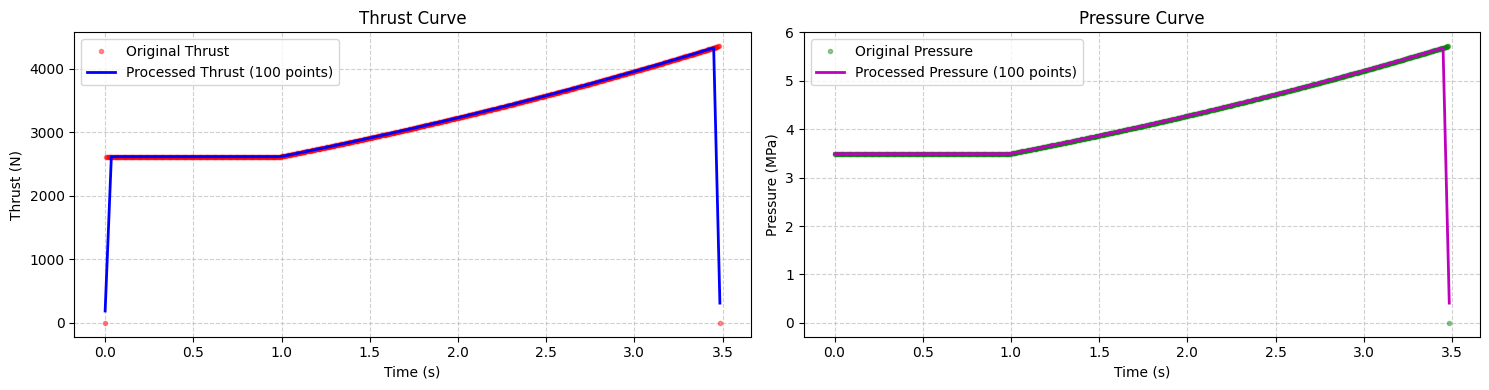

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import tensorflow as tf
import joblib
import warnings

# Ignore version warnings
warnings.filterwarnings('ignore')

# 1. Load the model and scalers
MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\inverse_rocket_model_fixed.keras"
inverse_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

s_X = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\scaler_X_inverse.pkl") # Scaler for input features (X)
s_y = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\scaler_y_inverse.pkl") # Scaler for output dimensions (y)

DIMENSION_NAMES = ['Length', 'Diameter', 'Core_Diameter', 'Rod_Diameter', 'Support_Diameter', 'Throat_Diameter', 'Exit_Diameter']

# 2. Directly ask for the file path or URL textually
print("="*60)
file_input = input("🔗 Enter Excel/CSV file URL or local path: ").strip('"\\') # Corrected: Trim quotes and backslashes
print("="*60)

if file_input:
    try:
        # Read file based on extension
        if file_input.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(file_input)
        else:
            df = pd.read_csv(file_input)

        print("✅ File loaded successfully.")

        # Clean and process data
        df.columns = df.columns.str.strip()

        REQUIRED_COLS = ['Time (s)', 'Thrust (N)', 'Pressure (MPa)']

        if not all(col in df.columns for col in REQUIRED_COLS):
            print(f"❌ Error: The file must contain columns: {REQUIRED_COLS}")
            print(f"Columns found in your file: {list(df.columns)}")
        else:
            # NUM_POINTS is defined in cell SnUAvFsmyp1n
            num_points_for_interp = 100 # Using 100 points as derived from NUM_POINTS in other cells

            df = df.dropna(subset=REQUIRED_COLS).sort_values('Time (s)')
            t = df['Time (s)'].values
            thrust = df['Thrust (N)'].values
            pressure = df['Pressure (MPa)'].values

            # Smoothing for both Thrust and Pressure
            thrust_smooth = savgol_filter(thrust, window_length=7, polyorder=3)
            pressure_smooth = savgol_filter(pressure, window_length=7, polyorder=3)

            # Interpolation to 100 points for each
            t_new = np.linspace(t[0], t[-1], num_points_for_interp)
            thrust_interp = interp1d(t, thrust_smooth, kind='linear', fill_value='extrapolate')(t_new)
            pressure_interp = interp1d(t, pressure_smooth, kind='linear', fill_value='extrapolate')(t_new)

            # 🚀 Concatenate Thrust and Pressure to make 200 features total
            X_input = np.concatenate([thrust_interp, pressure_interp]).reshape(1, -1)

            # Predict
            X_scaled = s_X.transform(X_input)
            y_pred_scaled = inverse_model.predict(X_scaled, verbose=0)
            y_pred = s_y.inverse_transform(y_pred_scaled)[0]

            # Print dimensions
            print("\n" + "-" * 50)
            print("🎯 Predicted Engineering Dimensions:")
            print("-" * 50)
            for i, name in enumerate(DIMENSION_NAMES):
                if i < len(y_pred):
                    print(f"  ➜ {name:<20}: {y_pred[i]:.4f}")
            print("-" * 50)

            # Plot both curves
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

            # Plot Thrust
            ax1.plot(t, thrust, 'r.', label='Original Thrust', alpha=0.4)
            ax1.plot(t_new, thrust_interp, 'b-', label='Processed Thrust (100 points)', linewidth=2)
            ax1.set_title("Thrust Curve")
            ax1.set_xlabel("Time (s)")
            ax1.set_ylabel("Thrust (N)")
            ax1.grid(True, linestyle='--', alpha=0.6)
            ax1.legend()

            # Plot Pressure
            ax2.plot(t, pressure, 'g.', label='Original Pressure', alpha=0.4)
            ax2.plot(t_new, pressure_interp, 'm-', label='Processed Pressure (100 points)', linewidth=2)
            ax2.set_title("Pressure Curve")
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel("Pressure (MPa)")
            ax2.grid(True, linestyle='--', alpha=0.6)
            ax2.legend()

            plt.tight_layout()
            plt.show()

    except FileNotFoundError:
        print(f"❌ Error: The file '{file_input}' was not found. Please ensure the path is correct and the file exists in the Colab environment or is a valid URL.")
    except Exception as e:
        print(f"❌ Error processing file: {e}")
else:
    print("⚠️ No input provided.")




In [10]:
import zipfile
import json
import shutil
import tempfile
import os

old_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\inverse_rocket_model.keras"
new_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\inverse_rocket_model_fixed.keras"

tmp_dir = tempfile.mkdtemp()

# فك الملف
with zipfile.ZipFile(old_model, "r") as z:
    z.extractall(tmp_dir)

config_path = os.path.join(tmp_dir, "config.json")

# تحميل config
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# حذف quantization_config من أي مستوى
def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)

    elif isinstance(obj, list):
        for item in obj:
            remove_quantization(item)

remove_quantization(config)

# حفظ config الجديد
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

# إعادة ضغط الملف
with zipfile.ZipFile(new_model, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(tmp_dir):
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, tmp_dir)
            z.write(full_path, rel_path)

print("DONE")
print(new_model)

DONE
M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\inverse_rocket_model_fixed.keras


In [14]:
MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Road and Tube\\inverse_rocket_model_fixed.keras"

inverse_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False,
    safe_mode=False
)

In [15]:
#MODEL_PATH = r"...inverse_rocket_model_fixed.keras"

from keras.models import load_model

model = load_model(
    MODEL_PATH,
    compile=False,
    safe_mode=False
)

print("SUCCESS")

SUCCESS


# X Grain Interface

✅ File loaded successfully.

--------------------------------------------------
🎯 Predicted Engineering Dimensions:
--------------------------------------------------
  ➜ Length              : 58.2750
  ➜ Diameter            : 6.4440
  ➜ Slot_Length         : 2.3126
  ➜ Slot_Width          : 1.1416
  ➜ Throat_Diameter     : 2.0022
  ➜ Exit_Diameter       : 2.9977
--------------------------------------------------


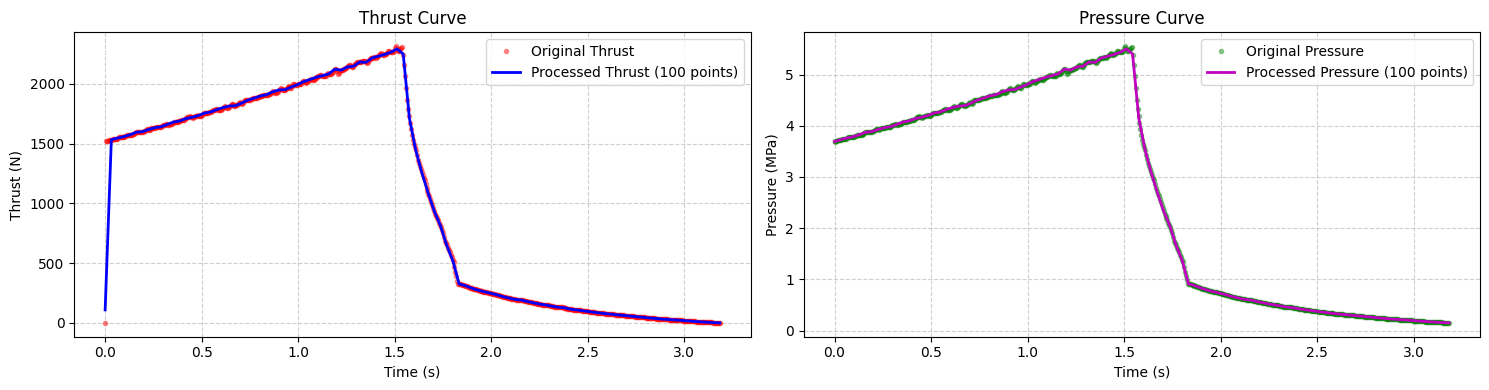

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import tensorflow as tf
import joblib
import warnings

# Ignore version warnings
warnings.filterwarnings('ignore')

# 1. Load the model and scalers
MODEL_PATH = "M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\best_X_model_fixed.keras"
inverse_model = tf.keras.models.load_model(MODEL_PATH, compile=False,safe_mode=False)

s_X = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\scaler_X_inverse.pkl") # Scaler for input features (X)
s_y = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\scaler_y_inverse.pkl") # Scaler for output dimensions (y)

DIMENSION_NAMES = ['Length', 'Diameter', 'Slot_Length', 'Slot_Width', 'Throat_Diameter', 'Exit_Diameter']

# 2. Directly ask for the file path or URL textually
print("="*60)
file_input = input("🔗 Enter Excel/CSV file URL or local path: ").strip('"\\') # Corrected: Trim quotes and backslashes
print("="*60)

if file_input:
    try:
        # Read file based on extension
        if file_input.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(file_input)
        else:
            df = pd.read_csv(file_input)

        print("✅ File loaded successfully.")

        # Clean and process data
        df.columns = df.columns.str.strip()

        REQUIRED_COLS = ['Time (s)', 'Thrust (N)', 'Pressure (MPa)']

        if not all(col in df.columns for col in REQUIRED_COLS):
            print(f"❌ Error: The file must contain columns: {REQUIRED_COLS}")
            print(f"Columns found in your file: {list(df.columns)}")
        else:
            # NUM_POINTS is defined in cell SnUAvFsmyp1n
            num_points_for_interp = 100 # Using 100 points as derived from NUM_POINTS in other cells

            df = df.dropna(subset=REQUIRED_COLS).sort_values('Time (s)')
            t = df['Time (s)'].values
            thrust = df['Thrust (N)'].values
            pressure = df['Pressure (MPa)'].values

            # Smoothing for both Thrust and Pressure
            thrust_smooth = savgol_filter(thrust, window_length=7, polyorder=3)
            pressure_smooth = savgol_filter(pressure, window_length=7, polyorder=3)

            # Interpolation to 100 points for each
            t_new = np.linspace(t[0], t[-1], num_points_for_interp)
            thrust_interp = interp1d(t, thrust_smooth, kind='linear', fill_value='extrapolate')(t_new)
            pressure_interp = interp1d(t, pressure_smooth, kind='linear', fill_value='extrapolate')(t_new)

            # 🚀 Concatenate Thrust and Pressure to make 200 features total
            X_input = np.concatenate([thrust_interp, pressure_interp]).reshape(1, -1)

            # Predict
            X_scaled = s_X.transform(X_input)
            y_pred_scaled = inverse_model.predict(X_scaled, verbose=0)
            y_pred = s_y.inverse_transform(y_pred_scaled)[0]

            # Print dimensions
            print("\n" + "-" * 50)
            print("🎯 Predicted Engineering Dimensions:")
            print("-" * 50)
            for i, name in enumerate(DIMENSION_NAMES):
                if i < len(y_pred):
                    print(f"  ➜ {name:<20}: {y_pred[i]:.4f}")
            print("-" * 50)

            # Plot both curves
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

            # Plot Thrust
            ax1.plot(t, thrust, 'r.', label='Original Thrust', alpha=0.4)
            ax1.plot(t_new, thrust_interp, 'b-', label='Processed Thrust (100 points)', linewidth=2)
            ax1.set_title("Thrust Curve")
            ax1.set_xlabel("Time (s)")
            ax1.set_ylabel("Thrust (N)")
            ax1.grid(True, linestyle='--', alpha=0.6)
            ax1.legend()

            # Plot Pressure
            ax2.plot(t, pressure, 'g.', label='Original Pressure', alpha=0.4)
            ax2.plot(t_new, pressure_interp, 'm-', label='Processed Pressure (100 points)', linewidth=2)
            ax2.set_title("Pressure Curve")
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel("Pressure (MPa)")
            ax2.grid(True, linestyle='--', alpha=0.6)
            ax2.legend()

            plt.tight_layout()
            plt.show()

    except FileNotFoundError:
        print(f"❌ Error: The file '{file_input}' was not found. Please ensure the path is correct and the file exists in the Colab environment or is a valid URL.")
    except Exception as e:
        print(f"❌ Error processing file: {e}")
else:
    print("⚠️ No input provided.")

In [59]:
import zipfile
import json
import shutil
import tempfile
import os

src_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\best_X_model.keras"
dst_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\best_X_model_fixed.keras"

tmp_dir = tempfile.mkdtemp()

# فك الملف
with zipfile.ZipFile(src_model, 'r') as z:
    z.extractall(tmp_dir)

config_path = os.path.join(tmp_dir, "config.json")

# تحميل config
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# حذف quantization_config من أي مكان
def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)
    elif isinstance(obj, list):
        for item in obj:
            remove_quantization(item)

remove_quantization(config)

# حفظ config المعدل
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

# إعادة ضغط الملف
with zipfile.ZipFile(dst_model, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(tmp_dir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, tmp_dir)
            z.write(full_path, arcname)

shutil.rmtree(tmp_dir)

print("Done!")
print(dst_model)

Done!
M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\X Models\\best_X_model_fixed.keras


# Star Grain Interface 


🔍 Reading performance profile: M:\Graduation Project\Team B\Code_project\test models\data\Star_4192.0.xlsx


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  ⚠️  ISP column not found — defaulting to estimated 170.0 s (typical star grain profile).

  🔩 Predicted Star Grain Dimensions (cm)
  Length              : 39.7064 cm
  Outer Diameter      : 15.8065 cm
  Number of Points    : 3.0006 cm
  Point Length        : 5.6038 cm
  Point Base Width    : 2.5972 cm
  Throat Diameter     : 1.9998 cm
  Exit Diameter       : 2.9996 cm
  (Metadata Profile → ISP: 170.0s | Impulse: 22138.0Ns | Burn: 8.96s | Max Thrust: 5005.4N)


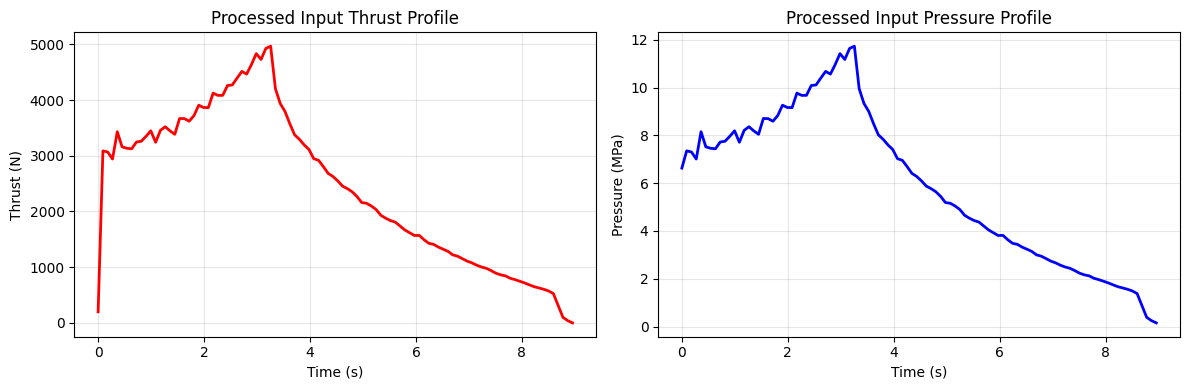

In [38]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

def predict_star_dims_from_file(file_path):
    """
    Input file (CSV or Excel) must have columns: Time, Thrust, Pressure
    Optional: ISP column
    
    Returns the 7 predicted Star Grain dimensions (cm).
    """
    print(f'\n🔍 Reading performance profile: {file_path}')

    if not os.path.exists(file_path):
        print(f"[Error]: Target file not found at path: {file_path}")
        return

    # ─── 1. Load Inverse Model and Scalers Safely ───
    try:
        # compile=False bypasses custom loss requirements during pure inference loading
        inverse_model = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Star Models\\Star_inverse_model.keras', compile=False)
        
        # Load the 4 specific Star Grain inverse scalers
        s_X  = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Star Models\\star_inv_scaler_dimensions.pkl')
        s_yt = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Star Models\\star_inv_scaler_thrust.pkl')
        s_yp = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Star Models\\star_inv_scaler_pressure.pkl')
        s_ys = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Star Models\\star_inv_scaler_scalars.pkl')
        
    except Exception as e:
        print(f"❌ Error loading system assets: {e}")
        print("Please verify 'Star_inverse_model.keras' and all 4 .pkl files are in your working directory.")
        return

    # ─── 2. Data File Parsing ───
    if file_path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip', skip_blank_lines=True)

    # ─── 3. Smart Column Detection ───
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if   'time' in c or c == 't':              col_map['time']     = col
        elif 'thrust' in c or c == 'f':            col_map['thrust']   = col
        elif 'pressure' in c or c == 'p':          col_map['pressure'] = col
        elif 'isp' in c:                           col_map['isp']      = col

    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        print(f'❌ Critical columns missing. Columns detected: {list(df.columns)}')
        return

    # Clean missing records and sort chronologically
    df = df.sort_values(col_map['time']).dropna(subset=[col_map['time'], col_map['thrust'], col_map['pressure']])
    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    # Apply Savitzky-Golay signal filtering if data density permits
    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # ─── 4. Uniform 100-Point Resampling interpolation ───
    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # ─── 5. Scalar Extraction ───
    burn_time     = t[-1]
    max_thrust    = np.max(thrust)
    total_impulse = trapezoid(thrust, t)
    
    if 'isp' in col_map:
        isp = df[col_map['isp']].iloc[0]
    else:
        print('  ⚠️  ISP column not found — defaulting to estimated 170.0 s (typical star grain profile).')
        isp = 170.0
        
    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    # ─── 6. Feature Scaling ───
    t_scaled = s_yt.transform(thrust_100.reshape(1, -1))
    p_scaled = s_yp.transform(pressure_100.reshape(1, -1))
    s_scaled = s_ys.transform(scalars.reshape(1, -1))

    # ─── 7. Deep Learning Inverse Prediction ───
    pred_s    = inverse_model.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    pred_dims = s_X.inverse_transform(pred_s)[0]
    pred_dims = np.maximum(pred_dims, 0.1)  # Physical safety guardrail

    # ─── 8. Print Predicted Structural Dimensions ───
    print('\n' + '='*55)
    print('  🔩 Predicted Star Grain Dimensions (cm)')
    print('='*55)
    labels = [
        'Length              ',
        'Outer Diameter      ',
        'Number of Points    ',
        'Point Length        ',
        'Point Base Width    ',
        'Throat Diameter     ',
        'Exit Diameter       ',
    ]
    for lbl, val in zip(labels, pred_dims):
        print(f'  {lbl}: {val:.4f} cm')
    print('='*55)
    print(f'  (Metadata Profile → ISP: {isp:.1f}s | Impulse: {total_impulse:.1f}Ns | Burn: {burn_time:.2f}s | Max Thrust: {max_thrust:.1f}N)')

    # ─── 9. Input Profiles Visualization Block ───
    plt.figure(figsize=(12, 4))
    
    # Thrust Verification Curve
    plt.subplot(1, 2, 1)
    plt.plot(x_new, thrust_100, color='red', linewidth=2)
    plt.title('Processed Input Thrust Profile')
    plt.xlabel('Time (s)')
    plt.ylabel('Thrust (N)')
    plt.grid(True, alpha=0.3)

    # Pressure Verification Curve
    plt.subplot(1, 2, 2)
    plt.plot(x_new, pressure_100, color='blue', linewidth=2)
    plt.title('Processed Input Pressure Profile')
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (MPa)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Explicit mapping definitions to avoid dictionary return runtime errors
    DIM_NAMES = ['Length', 'Outer_Diameter', 'Number_of_Points', 'Point_Length', 'Point_Base_Width', 'Throat_Diameter', 'Exit_Diameter']
    return dict(zip(DIM_NAMES, pred_dims))


# =====================================================================
# 10. Execution Entry point
# =====================================================================
file_path = "M:\\Graduation Project\\Team B\\Code_project\\test models\\data\\Star_4192.0.xlsx"
predicted_dimensions = predict_star_dims_from_file(file_path)

# Conical Grain Interface

In [42]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

MODEL_PATH = "M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Conical Models\\Conical_Reverse_Model.keras"
conical_reverse = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

def predict_conical_dimensions_from_file_v2(file_path):
    print(f"\n🔍 Reading file: {file_path}")

    try:
        max_vals = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Conical Models\\conical_rev_max_values.pkl')
        s_xs     = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Conical Models\\conical_rev_scaler_scalars.pkl')
        s_Y      = joblib.load('Reverse Models/Conical Models/conical_rev_scaler_dims.pkl')
        xt_max   = max_vals['xt_max']
        xp_max   = max_vals['xp_max']
    except Exception as e:
        print(f"❌ Error loading scalers: {e}")
        return

    # قراءة الملف
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')

    df.columns = df.columns.str.strip()

    # التعرف على الأعمدة
    col_map = {}
    for col in df.columns:
        c = col.lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if 'time' in c:     col_map['time']     = col
        elif 'thrust' in c: col_map['thrust']   = col
        elif 'pressure' in c: col_map['pressure'] = col

    print(f"📋 Detected columns: {col_map}")

    required = ['time', 'thrust', 'pressure']
    for r in required:
        if r not in col_map:
            print(f"❌ Missing required column: {r}")
            return

    df = df.sort_values(col_map['time']).dropna(
        subset=[col_map['time'], col_map['thrust'], col_map['pressure']]
    )

    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    # Smoothing (نفس التدريب بالظبط)
    # if len(thrust) > 7:
    #     thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
    #     pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # Interpolate لـ 100 نقطة (نفس التدريب)
    x_new = np.linspace(t[0], t[-1], 100)
    t_100 = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    p_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # ============================================================
    # حساب الـ Scalars بنفس طريقة التدريب بالظبط
    # ============================================================
    burn_time    = t[-1]                          # نفس t[-1] في التدريب
    max_thrust   = np.max(thrust)                 # نفس np.max(thrust)
    total_impulse = trapezoid(thrust, t)          # نفس trapezoid في التدريب ✅

    # ISP: في التدريب اتاخد من عمود جاهز (mean≈167, std≈2.9)
    # نحسبه فيزيائياً: ISP = Total_Impulse / (m_dot_avg × g × burn_time)
    # بما إن مش عندنا كتلة، نستخدم التقريب:
    # ISP ≈ Total_Impulse / (avg_thrust × burn_time / g)
    # لكن ده بيطلع نفس رقم ثابت تقريباً
    # الأسلم: استخدم median قيم ISP من التدريب (≈168)
    # لأن range التدريب: 152–174 وstd=2.9 (ضيق جداً)
    isp = float(df[col_map['isp']].iloc[0]) if 'isp' in col_map else 170.0  # Default to mean ISP if not provided
    # تأكد إن في range التدريب (152–174)
    isp = np.clip(isp, 152.0, 174.0)

    print(f"📊 Computed scalars:")
    print(f"   ISP           = {isp:.2f} s")
    print(f"   Total Impulse = {total_impulse:.2f} Ns")
    print(f"   Burn Time     = {burn_time:.3f} s")
    print(f"   Max Thrust    = {max_thrust:.2f} N")

    scalars = np.array([[isp, total_impulse, burn_time, max_thrust]])

    # Scaling (نفس التدريب)
    t_scaled = (t_100 / xt_max).reshape(1, -1)
    p_scaled = (p_100 / xp_max).reshape(1, -1)
    s_scaled = s_xs.transform(scalars)

    # التنبؤ
    pred_scaled = conical_reverse.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    pred_dims   = s_Y.inverse_transform(pred_scaled)[0]
    pred_dims   = np.maximum(pred_dims, 0.01)

    DIM_LABELS = ['Length', 'Diameter', 'Forward_Core_Diameter',
                  'Aft_Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']

    print("\n" + "="*50)
    print(f"{'Dimension':<25} | {'Predicted (cm)':<15} | {'Expected'}")
    print("-" * 60)
    expected = [20, 8, 3, 7, 1.2, 1.8]
    for label, val, exp in zip(DIM_LABELS, pred_dims, expected):
        err = abs(val - exp) / exp * 100
        print(f"{label:<25} | {val:>10.4f}     | {exp:.1f}  (err={err:.1f}%)")
    print("="*50)

    return dict(zip(DIM_LABELS, pred_dims))

result = predict_conical_dimensions_from_file_v2("M:\\Graduation Project\\Team B\\Code_project\\test models\\data\\conical_2440.0.xlsx")


🔍 Reading file: M:\Graduation Project\Team B\Code_project\test models\data\conical_2440.0.xlsx
📋 Detected columns: {'time': 'Time (s)', 'pressure': 'Pressure (MPa)', 'thrust': 'Thrust (N)'}
📊 Computed scalars:
   ISP           = 170.00 s
   Total Impulse = 6135.59 Ns
   Burn Time     = 2.890 s
   Max Thrust    = 3895.22 N


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



Dimension                 | Predicted (cm)  | Expected
------------------------------------------------------------
Length                    |   102.9399     | 20.0  (err=414.7%)
Diameter                  |     6.0719     | 8.0  (err=24.1%)
Forward_Core_Diameter     |     3.0264     | 3.0  (err=0.9%)
Aft_Core_Diameter         |     3.5087     | 7.0  (err=49.9%)
Throat_Diameter           |     2.3266     | 1.2  (err=93.9%)
Exit_Diameter             |     3.4917     | 1.8  (err=94.0%)


# Finocyl Grain Interface

c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ctrl-Halim\AppData\Local\Temp\ipykernel_12540\3487113002.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead,


  Predicted Geometry
  Diameter               :    6.239  cm
  Length                 :   25.591  cm
  Core_Diameter          :    2.019  cm
  Number_Of_Fins         :    5.924  —
  Fin_Length             :    1.069  cm
  Fin_Width              :    0.613  cm
  Throat_Diameter        :    1.011  cm
  Exit_Diameter          :    1.517  cm
  Burn Time   : 2.080 s
  Max Thrust  : 998.80 N
  Max Pressure: 10.12 MPa
  Total Impulse: 1264.0 Ns


C:\Users\Ctrl-Halim\AppData\Local\Temp\ipykernel_12540\3487113002.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Total Impulse: {np.trapz(thrust, t):.1f} Ns")


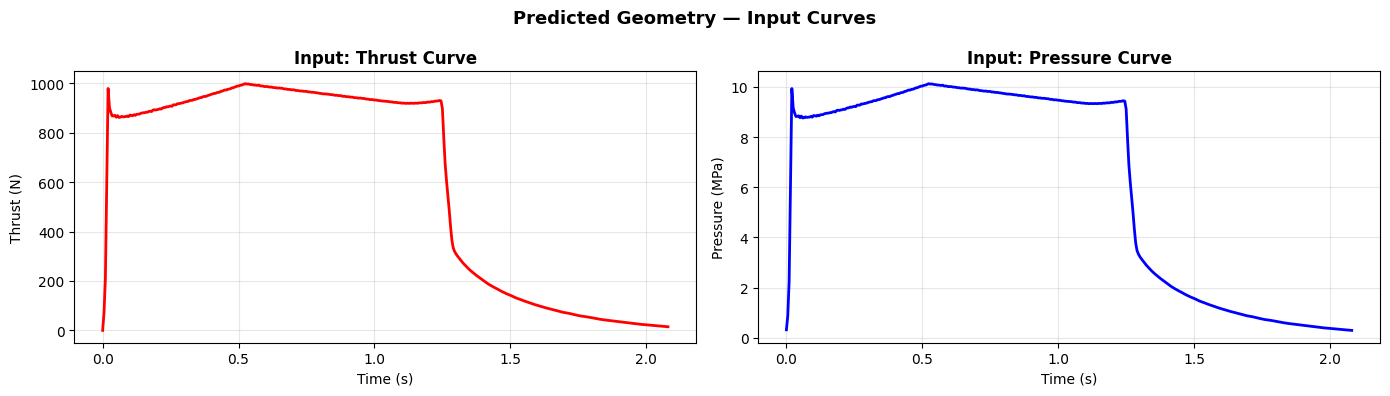

In [50]:
# ============================================================
# PREDICTION FUNCTION v2
# ============================================================
INPUT_COLS = ['Diameter', 'Length', 'Core_Diameter', 'Number_Of_Fins',
            'Fin_Length', 'Fin_Width', 'Throat_Diameter', 'Exit_Diameter']
inv_model_v2 = tf.keras.models.load_model(
    "M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Finocyl Models\\finocyl_inv_best_v2.keras",
    compile=False
)
inv_scaler_Y = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Finocyl Models\\finocyl_inv_scaler_Y_v2.pkl")
inv_scaler_S = joblib.load("M:\\Graduation Project\\Team B\\Code_project\\test models\\Reverse Models\\Finocyl Models\\finocyl_inv_scaler_S_v2.pkl")
def predict_geometry_v2(file_path,
                        model=inv_model_v2,
                        scaler_Y=inv_scaler_Y,
                        scaler_S=inv_scaler_S,
                        num_points=128,
                        label="Predicted Geometry"):
    """
    يأخذ ملف Excel/CSV يحتوي على [Time (s), Pressure (MPa), Thrust (N)]
    ويُرجع الأبعاد الهندسية الـ 8 المتوقعة.
    
    الفرق عن الإصدار القديم: يستخدم أيضًا الـ scalar features
    (Max Thrust, Burn Time, إلخ) لتحسين الدقة بشكل جذري.
    """
    if file_path.endswith(('.xlsx', '.xls')):
        raw = pd.read_excel(file_path)
    else:
        raw = pd.read_csv(file_path, on_bad_lines='skip')
    raw.columns = raw.columns.str.strip()

    for col in ['Time (s)', 'Pressure (MPa)', 'Thrust (N)']:
        if col not in raw.columns:
            raise ValueError(f"Missing column: '{col}'")

    raw    = raw.dropna().sort_values('Time (s)')
    t      = raw['Time (s)'].values.astype(float)
    thrust = np.clip(raw['Thrust (N)'].values.astype(float), 0, None)
    press  = np.clip(raw['Pressure (MPa)'].values.astype(float), 0, None)
    def extract_scalar_features(t, thrust, press):
        """
        استخراج 6 features مطلقة من كل curve.
        هذه الـ features تحمل المعلومات التي تُفقدها الـ normalization.
        """
        max_thrust    = np.max(thrust)
        max_press     = np.max(press)
        burn_time     = t[-1]                     # المدة الفعلية بالثواني
        avg_thrust    = np.trapz(thrust, t) / (burn_time + 1e-8)
        total_impulse = np.trapz(thrust, t)
        
        # Rise time: الوقت للوصول لـ 90% من max thrust
        idx_90 = np.argmax(thrust >= 0.9 * max_thrust)
        rise_time = t[idx_90] / (burn_time + 1e-8) if max_thrust > 0 else 0.5
        
        return np.array([
            np.log1p(max_thrust),      # log scale لتقليل skewness
            np.log1p(max_press),
            np.log1p(burn_time),
            np.log1p(avg_thrust),
            np.log1p(total_impulse),
            rise_time
        ], dtype=np.float32)
    # Scalar features (قبل normalization)
    scalars = extract_scalar_features(t, thrust, press)
    scalars_s = scaler_S.transform(scalars.reshape(1, -1))

    # Curve normalization
    t_norm = (t - t[0]) / (t[-1] - t[0])
    t_new  = np.linspace(0, 1, num_points)
    thr_r  = np.clip(interp1d(t_norm, thrust, kind='linear',
                               fill_value='extrapolate')(t_new), 0, None)
    prs_r  = np.clip(interp1d(t_norm, press,  kind='linear',
                               fill_value='extrapolate')(t_new), 0, None)

    thr_r /= (np.max(thr_r) + 1e-8)
    prs_r /= (np.max(prs_r) + 1e-8)
    thr_r  = np.clip(savgol_filter(thr_r, 15, 3), 0, None)
    prs_r  = np.clip(savgol_filter(prs_r, 15, 3), 0, None)

    pred_s = model.predict(
        [thr_r.reshape(1, num_points),
         prs_r.reshape(1, num_points),
         scalars_s], verbose=0)
    pred   = scaler_Y.inverse_transform(pred_s)[0]
    result = dict(zip(INPUT_COLS, pred))

    print("\n" + "="*52)
    print(f"  {label}")
    print("="*52)
    units = ['cm','cm','cm','—','cm','cm','cm','cm']
    for (k, v), u in zip(result.items(), units):
        print(f"  {k:<22} : {v:>8.3f}  {u}")
    print("="*52)
    print(f"  Burn Time   : {t[-1]:.3f} s")
    print(f"  Max Thrust  : {np.max(thrust):.2f} N")
    print(f"  Max Pressure: {np.max(press):.2f} MPa")
    print(f"  Total Impulse: {np.trapz(thrust, t):.1f} Ns")
    print("="*52)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(t, thrust, color='red',  lw=2)
    axes[0].set_title('Input: Thrust Curve', fontweight='bold')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t, press, color='blue', lw=2)
    axes[1].set_title('Input: Pressure Curve', fontweight='bold')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'{label} — Input Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{label.replace(" ","_")}_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    return result


# ← ضع مسار ملف الـ CSV/Excel هنا
result1 = predict_geometry_v2("M:\\Graduation Project\\Team B\\Code_project\\test models\\data\\Finocyl_2.0.xlsx")
